# Show each layer's activations of BSARec

## Get the input + load the model

In [ ]:
import os
os.chdir("..")

In [1]:
import datetime
from types import SimpleNamespace
from dataset import get_seq_dic, get_dataloder, get_rating_matrix

def get_local_time():
    cur = datetime.datetime.now()
    cur = cur.strftime('%b-%d-%Y_%H-%M-%S')

    return cur

args = {}
args["data_dir"]= "./data/"
args["output_dir"]= "/scratch-shared/recsys/"
args["data_name"]= "LastFM"
args["do_eval"]= True
args["load_model"]="/scratch-shared/recsys/BSARec_LastFM_lr_0.001_bs_256_ep_200_seed_1417"
args["train_name"]=get_local_time()
args["num_items"]=10
args["num_users"]=10

# train args
args["lr"]=0.0005
args["batch_size"]=256
args["epochs"]=200
args["no_cuda"]= True
args["log_freq"]=1
args["patience"]=10
args["num_workers"]=4
args["c"]=3
args["alpha"]=0.9

args["seed"]=42
args["weight_decay"]=0.0
args["adam_beta1"]=0.9
args["adam_beta2"]=0.999
args["gpu_id"]= "0"
args["variance"]=5

# model args
args["model_type"]='BSARec'
args["max_seq_length"]=50
args["hidden_size"]=64
args["num_hidden_layers"]=2
args["hidden_act"]= "gelu"
args["num_attention_heads"]=2
args["attention_probs_dropout_prob"]=0.5
args["hidden_dropout_prob"]=0.5
args["initializer_range"]=0.02

# for wandb only
args["project"] = 'BSARec'
args["run_name"] = 'BSARec'

# saving all model logits
args["save"]=True
args["save_path"]="output/"

args["spectral"]=True
args = SimpleNamespace(**args)

seq_dic, max_item, num_users = get_seq_dic(args)
args.item_size = max_item + 1
args.num_users = num_users + 1
args.valid_rating_matrix, args.test_rating_matrix = get_rating_matrix(args.data_name, seq_dic, max_item)

/home/scur2701/.conda/envs/bsarec/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import torch
import numpy as np

from model import MODEL_DICT
from trainers import Trainer
from utils import EarlyStopping, check_path, set_seed, set_logger
from dataset import get_seq_dic, get_dataloder, get_rating_matrix
import wandb
from types import SimpleNamespace
from model.bsarec import FrequencyLayer

log_path = os.path.join(args.output_dir, args.train_name + '.log')
logger = set_logger(log_path)

set_seed(args.seed)
check_path(args.output_dir)

os.environ["CUDA_VISIBLE_DEVICES"] = args.gpu_id
args.cuda_condition = torch.cuda.is_available() and not args.no_cuda

seq_dic, max_item, num_users = get_seq_dic(args)
args.item_size = max_item + 1
args.num_users = num_users + 1

args.checkpoint_path = os.path.join(args.output_dir, args.train_name + '.pt')
args.same_target_path = os.path.join(args.data_dir, args.data_name+'_same_target.npy')


In [3]:
from trainers import Trainer


SAVE_TENSORS_FILE_BSA_REC = f"./analysis_lastfm_bsarec_tensors.pt"
SAVE_TENSORS_REMOVE_PADDING = f"./analysis_lastfm_bsarec_nopadding.pt"
SAVE_TENSORS_REFLECT_PADDING = f"./analysis_lastfm_bsarec_reflect_padding.pt"
SAVE_TENSORS_CIRCULAR_PADDING = f"./analysis_lastfm_bsarec_circular_padding.pt"

args.checkpoint_path = os.path.join(args.output_dir, args.load_model + '.pt')


def save_bsarec_file(checkpoint_path, model_type=args.model_type.lower(), padding="zero", save_file=SAVE_TENSORS_FILE_BSA_REC):
    args.checkpoint_path = checkpoint_path
    args.model_type = model_type
    args.padding = padding
    train_dataloader, eval_dataloader, test_dataloader, _ = get_dataloder(args,seq_dic)

    # logger.info(str(args))
    model = MODEL_DICT[model_type](args=args)
    # logger.info(model)
    trainer = Trainer(model, train_dataloader, eval_dataloader, test_dataloader, args, logger, wandb=False)
    trainer.load(checkpoint_path, map_location=torch.device('cpu'))

    logger.info(f"Load model from {checkpoint_path} for test!")
    # scores, result_info = trainer.test(epoch=args.epochs - 1, save=args.save, spectral=args.spectral)
    trainer.model.eval()

    trainer.model.eval()
    with torch.no_grad():
        batch = next(iter(eval_dataloader))
        batch = tuple(t.to(trainer.device) for t in batch)
        user_ids, input_ids, answers, neg_answer, same_target = batch
        trainer.model.to(trainer.device)

        # put input through positional embeddings
        pos_emb_input = trainer.model.add_position_embedding(input_ids)
        att_mask = trainer.model.get_attention_mask(input_ids)

        # first block layer

        # Get high and low frequencies
        freqs_input = torch.clone(pos_emb_input)

        _, seq_len, _ = freqs_input.shape
        x = torch.fft.rfft(freqs_input, dim=1, norm='ortho')
        
        low_pass = x[:]
        low_pass[:, trainer.model.item_encoder.blocks[0].layer.filter_layer.c:, :] = 0
        low_pass = torch.fft.irfft(low_pass, n=seq_len, dim=1, norm='ortho')
        high_pass = freqs_input - low_pass
        sequence_emb_fft = low_pass + (trainer.model.item_encoder.blocks[0].layer.filter_layer.sqrt_beta**2) * high_pass

        # Get combined frequencies
        filter_out = trainer.model.item_encoder.blocks[0].layer.filter_layer.LayerNorm(sequence_emb_fft + freqs_input)

        # Get multi-head attention layer
        mha_tensor = torch.clone(pos_emb_input)
        mha_tensor = trainer.model.item_encoder.blocks[0].layer.attention_layer(mha_tensor, att_mask)

        # get first block combined
        hidden_states = trainer.model.item_encoder.blocks[0].layer.alpha * filter_out + ( 1 - trainer.model.item_encoder.blocks[0].layer.alpha ) * mha_tensor

        # pass through the FFNN
        output_block = trainer.model.item_encoder.blocks[0].feed_forward(hidden_states)

        # second block layer
        output_block_all = torch.clone(pos_emb_input)
        output_block_all = trainer.model.item_encoder.blocks[0](output_block_all, att_mask)

        # Get high and low frequencies
        pos_emb_input2 = torch.clone(output_block_all)
        freqs_input2 = torch.clone(pos_emb_input2)

        _, seq_len, _ = freqs_input2.shape
        x2 = torch.fft.rfft(freqs_input2, dim=1, norm='ortho')
        
        low_pass2 = x2[:]
        low_pass2[:, trainer.model.item_encoder.blocks[1].layer.filter_layer.c:, :] = 0
        low_pass2 = torch.fft.irfft(low_pass2, n=seq_len, dim=1, norm='ortho')
        high_pass2 = freqs_input2 - low_pass2
        sequence_emb_fft2 = low_pass2 + (trainer.model.item_encoder.blocks[1].layer.filter_layer.sqrt_beta**2) * high_pass2

        # Get combined frequencies
        filter_out2 = trainer.model.item_encoder.blocks[1].layer.filter_layer.LayerNorm(sequence_emb_fft2 + freqs_input2)

        # Get multi-head attention layer
        mha_tensor2 = torch.clone(pos_emb_input2)
        mha_tensor2 = trainer.model.item_encoder.blocks[1].layer.attention_layer(mha_tensor2, att_mask)

        # get first block combined
        hidden_states2 = trainer.model.item_encoder.blocks[1].layer.alpha * filter_out2 + ( 1 - trainer.model.item_encoder.blocks[1].layer.alpha ) * mha_tensor2

        # pass through the FFNN
        output_block2 = trainer.model.item_encoder.blocks[1].feed_forward(hidden_states2)

        # second block layer
        output_block_all2 = torch.clone(pos_emb_input2)
        pos_emb_input = trainer.model.add_position_embedding(input_ids)
        att_mask = trainer.model.get_attention_mask(input_ids)
        output_block_all2 = trainer.model.forward(input_ids)

        


        tensor_dict = {
            "original_users": user_ids.cpu(),
            "original_input": input_ids.cpu(),
            "positional_embedding_input": pos_emb_input.cpu(),
            "low_pass_component": low_pass.cpu(),
            "high_pass_component": high_pass.cpu(),
            "sequence_emb_fft": sequence_emb_fft.cpu(),
            "filtered_output": filter_out.cpu(),
            "multihead_attention_output": mha_tensor.cpu(),
            "combined_hidden_state": hidden_states.cpu(),
            "full_block_manual": output_block.cpu(),
            "full_block_output": output_block_all.cpu(),
            "low_pass_component2": low_pass2.cpu(),
            "high_pass_component2": high_pass2.cpu(),
            "sequence_emb_fft2": sequence_emb_fft2.cpu(),
            "filtered_output2": filter_out2.cpu(),
            "multihead_attention_output2": mha_tensor2.cpu(),
            "combined_hidden_state2": hidden_states2.cpu(),
            "full_block_manual2": output_block2.cpu(),
            "full_block_output2": output_block_all2.cpu()
        }

        torch.save(tensor_dict, save_file)
        
        # Check to see if no steps were skipped
        assert torch.equal(output_block, output_block_all)
        assert torch.equal(output_block2, output_block_all2)

# save_bsarec_file("/scratch-shared/recsys/BSARec_LastFM_lr_0.001_bs_256_ep_200_seed_1417", "BSARec", "zero", )

In [6]:
save_bsarec_file("/scratch-shared/recsys/BSARec_LastFM_lr_0.001_bs_256_ep_200_seed_1417.pt", model_type="bsarec", padding="zero", save_file=SAVE_TENSORS_FILE_BSA_REC)

save_bsarec_file("/scratch-shared/recsys/BSARec_Padding_LastFM_lr_0.001_bs_256_ep_200_padding_reflect_no_padding_False_seed_40.pt", "bsarec", "reflect", SAVE_TENSORS_REFLECT_PADDING)

save_bsarec_file("/scratch-shared/recsys/BSARec_Padding_LastFM_lr_0.001_bs_256_ep_200_padding_cyclic_no_padding_False_seed_37.pt", "bsarec", "cyclic", SAVE_TENSORS_CIRCULAR_PADDING)

2025-06-22 20:11:51,761 - Total Parameters: 337088
2025-06-22 20:11:51,764 - odict_keys(['item_embeddings.weight', 'position_embeddings.weight', 'LayerNorm.weight', 'LayerNorm.bias', 'item_encoder.blocks.0.layer.filter_layer.sqrt_beta', 'item_encoder.blocks.0.layer.filter_layer.LayerNorm.weight', 'item_encoder.blocks.0.layer.filter_layer.LayerNorm.bias', 'item_encoder.blocks.0.layer.attention_layer.query.weight', 'item_encoder.blocks.0.layer.attention_layer.query.bias', 'item_encoder.blocks.0.layer.attention_layer.key.weight', 'item_encoder.blocks.0.layer.attention_layer.key.bias', 'item_encoder.blocks.0.layer.attention_layer.value.weight', 'item_encoder.blocks.0.layer.attention_layer.value.bias', 'item_encoder.blocks.0.layer.attention_layer.dense.weight', 'item_encoder.blocks.0.layer.attention_layer.dense.bias', 'item_encoder.blocks.0.layer.attention_layer.LayerNorm.weight', 'item_encoder.blocks.0.layer.attention_layer.LayerNorm.bias', 'item_encoder.blocks.0.feed_forward.dense_1.weigh

## Load the tensor files and get graphs

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

def load_tensor_dict(pt_path):
    data = torch.load(pt_path, map_location='cpu')
    return data

def compute_l2_norms(tensor_dict, tensor_names):
    norms = {}
    for name in tensor_names:
        if len(tensor_dict[name].shape) < 3:
            norms[name] = tensor_dict[name].cpu().numpy()
        else:
            arr = tensor_dict[name].cpu().numpy()
            norms[name] = np.linalg.norm(arr, axis=-1)
    return norms

def plot_user_barplots(tensor_dict, norms_dict, tensor_names, inputs,
                       n_users=5, save_dir="barplots"):
    """
    For each of the first n_users:
      - Colors bars by item ID mapped to class-color
      - Displays inline and saves PNGs
    """
    os.makedirs(save_dir, exist_ok=True)
    n_tensors = len(tensor_names)
    n_items = norms_dict[tensor_names[0]].shape[1]
    x = np.arange(n_items)

    for user_idx in range(min(n_users, norms_dict[tensor_names[0]].shape[0])):
        # build RGBA color per item
        item_ids = tensor_dict[inputs][user_idx]
        colors_rgba = []
        for itm in item_ids:
            if itm == 0:
                color = 'grey'
            else:
                color = "turquoise"
            try:
                rgba = mcolors.to_rgba(color)
            except ValueError:
                rgba = mcolors.to_rgba('black')
            colors_rgba.append(rgba)

        fig, axes = plt.subplots(1, n_tensors, figsize=(4 * n_tensors, 4), squeeze=False)
        axes = axes.flatten()
        for ax, name in zip(axes, tensor_names):
            user_vec = norms_dict[name][user_idx]
            ax.bar(x, user_vec, color=colors_rgba)
            ax.set_title(f"{name}\nUser {user_idx}")
            ax.set_xlabel("Item index")
            ax.set_ylabel("L2 norm")
            ax.set_xticks(x)
            ax.set_xticklabels(x, rotation=90)

        plt.tight_layout()
        out_path = os.path.join(save_dir, f"user_{user_idx:02d}_barplots.png")
        fig.savefig(out_path, dpi=150)
        print(f"Saved bar plot for user {user_idx} at {out_path}")
        plt.show()


def plot_user_barplots_three(tensor_dict,
                              norms_dict_zero,
                              norms_dict_reflect,
                              norms_dict_cyclic,
                              tensor_names,
                              inputs,
                              n_users=5,
                              save_dir="barplots",
                              font_size=22):
    """
    For each of the first n_users:
      - Colors bars by item ID mapped to class-color
      - Displays inline and saves PNGs
      - Plots three padding variants on three rows: zero padding, reflect, cyclic
      - Ensures all columns share the same y-axis scaling per user
    """
    os.makedirs(save_dir, exist_ok=True)
    n_tensors = len(tensor_names)
    n_items = norms_dict_zero[tensor_names[0]].shape[1]
    x = np.arange(n_items)
    actual_color = plt.get_cmap('tab20').colors[0]
    plt.rcParams.update({'font.size': font_size})

    for user_idx in range(min(n_users, norms_dict_zero[tensor_names[0]].shape[0])):
        max_vals = []
        for norm_dict in (norms_dict_zero, norms_dict_reflect, norms_dict_cyclic):
            for name in tensor_names:
                max_vals.append(np.max(norm_dict[name][user_idx]))
        global_max = max(max_vals)

        item_ids = tensor_dict[inputs][user_idx]
        colors = [ 'darkgrey' if itm == 0 else actual_color for itm in item_ids ]

        fig, axes = plt.subplots(2, n_tensors, figsize=(4 * n_tensors, 6), squeeze=True, sharex=True, sharey=True)

        row_titles = ['zero', 'reflect']
        norm_dicts = [norms_dict_zero, norms_dict_reflect]

        tensor_names_titles = ["Low-frequency", "High-frequency"]

        for row_idx, (title, norm_dict) in enumerate(zip(row_titles, norm_dicts)):
            for col, name in enumerate(tensor_names):
                ax = axes[row_idx, col]
                user_vec = norm_dict[name][user_idx]
                ax.bar(x, user_vec, color=colors)
                ax.set_title(f"{tensor_names_titles[col]} ({title})")
                if col == 0:
                    ax.set_ylabel("L2 norm")
                ax.set_xlabel("Item index")
                ax.set_xticks([])
                ax.set_ylim(0, global_max * 1.05)
        # fig.suptitle("Padding types on BSARec LastFM histories", fontsize=16)

        padding_patch = mpatches.Patch(color='darkgrey', label='Padding')
        actual_patch = mpatches.Patch(color=actual_color, label='Actual Items')
        fig.legend(handles=[padding_patch, actual_patch], loc="lower center", frameon=False, ncol=2)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fig.subplots_adjust(bottom=0.12)
        # plt.tight_layout()

        out_path = os.path.join(save_dir, f"user_{user_idx:02d}_barplots.png")
        fig.savefig(out_path, dpi=150)
        out_path = os.path.join(save_dir, f"user_{user_idx:02d}_barplots.pdf")
        fig.savefig(out_path, dpi=300, format="pdf")
        print(f"Saved bar plot for user {user_idx} at {out_path}")
        plt.show()

In [12]:
tensor_names = [
            "original_users",
            "original_input",
            "positional_embedding_input",
            "low_pass_component",
            "high_pass_component",
            "sequence_emb_fft",
            "filtered_output",
            "multihead_attention_output",
            "combined_hidden_state",
            "full_block_manual",
            "full_block_output",
            "low_pass_component2",
            "high_pass_component2",
            "sequence_emb_fft2",
            "filtered_output2",
            "multihead_attention_output2",
            "combined_hidden_state2",
            "full_block_manual2",
            "full_block_output2"
        ]
tensor_dict = load_tensor_dict(SAVE_TENSORS_FILE_BSA_REC)

tensor_dict = compute_l2_norms(tensor_dict, tensor_names)

selected_tensors = [
    # "original_input",
    "low_pass_component",
    "high_pass_component",
    # "filtered_output",
    # "multihead_attention_output",
    # "combined_hidden_state",
    # "low_pass_component2",
    # "high_pass_component2",
    # "filtered_output2",
    # "multihead_attention_output2"
]

Saved bar plot for user 0 at barplots/user_00_barplots.png


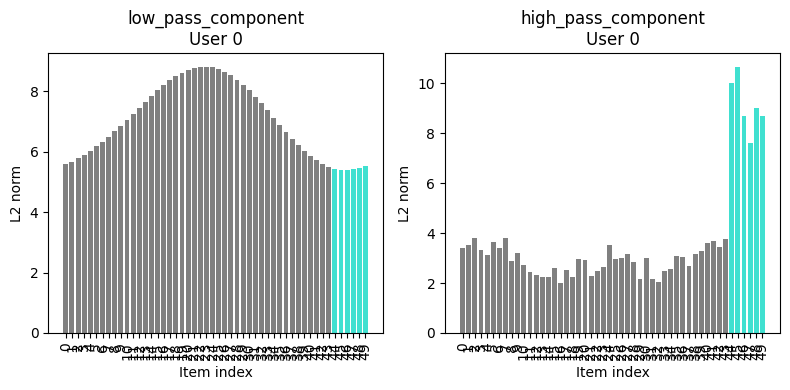

Saved bar plot for user 1 at barplots/user_01_barplots.png


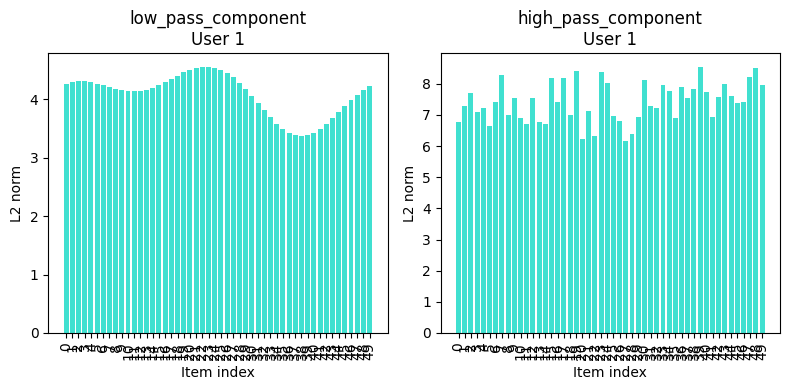

Saved bar plot for user 2 at barplots/user_02_barplots.png


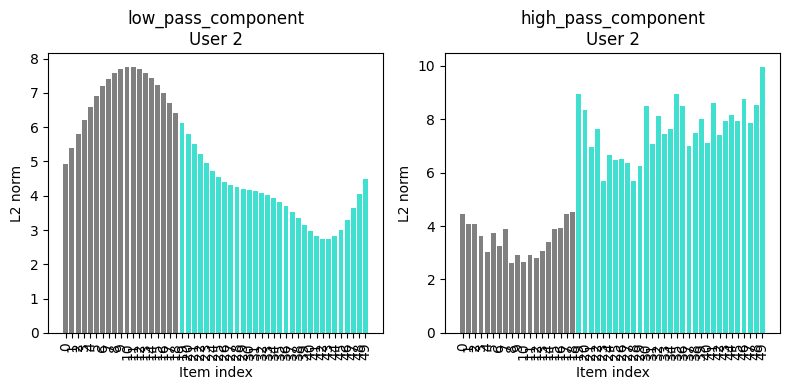

Saved bar plot for user 3 at barplots/user_03_barplots.png


KeyboardInterrupt: 

In [9]:
n = 10

plot_user_barplots(tensor_dict, tensor_dict, selected_tensors, inputs="original_input", n_users=n)

Saved bar plot for user 0 at barplots/user_00_barplots.pdf


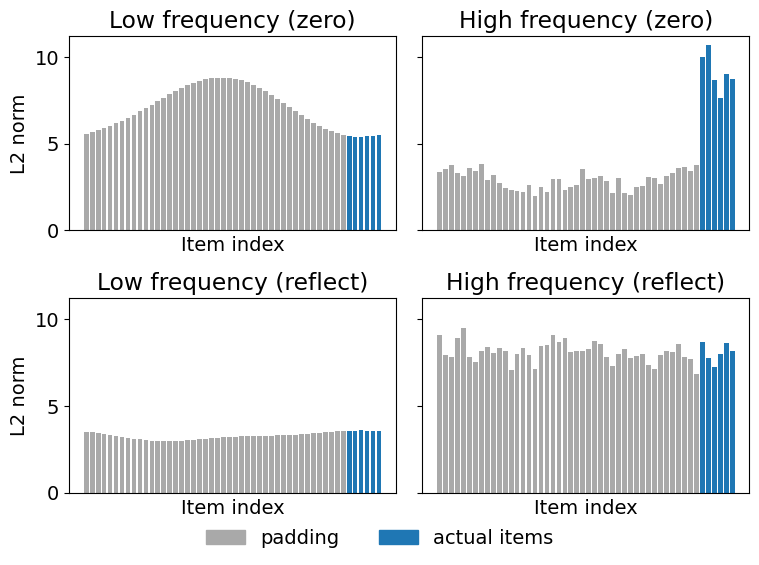

Saved bar plot for user 1 at barplots/user_01_barplots.pdf


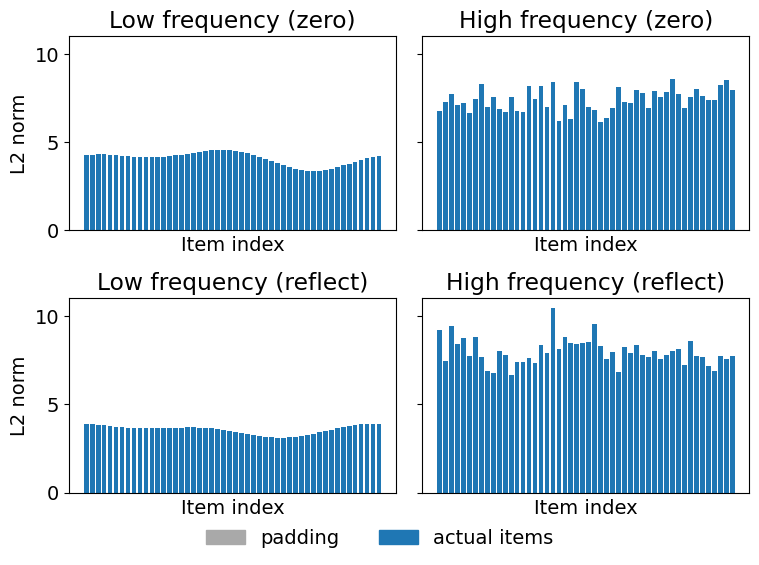

Saved bar plot for user 2 at barplots/user_02_barplots.pdf


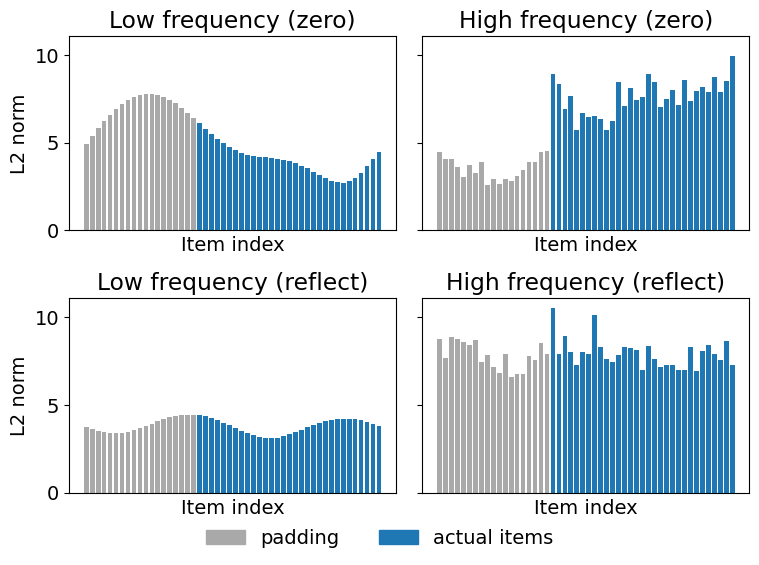

Saved bar plot for user 3 at barplots/user_03_barplots.pdf


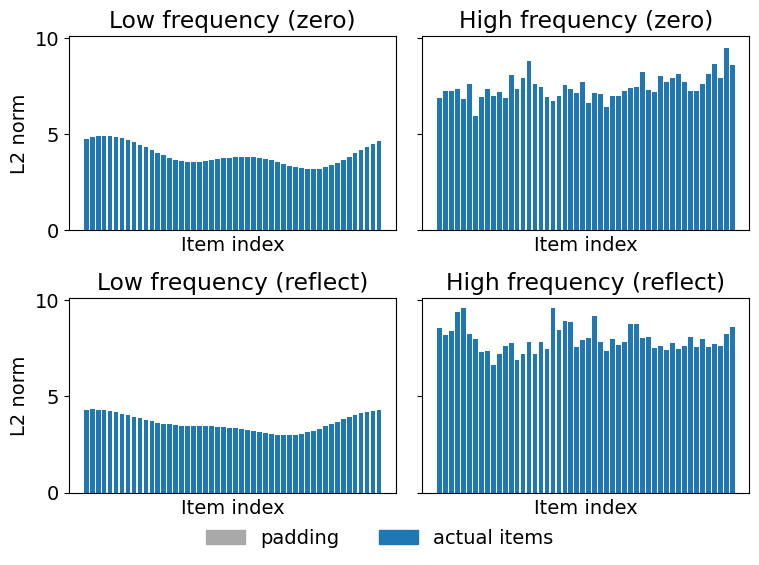

Saved bar plot for user 4 at barplots/user_04_barplots.pdf


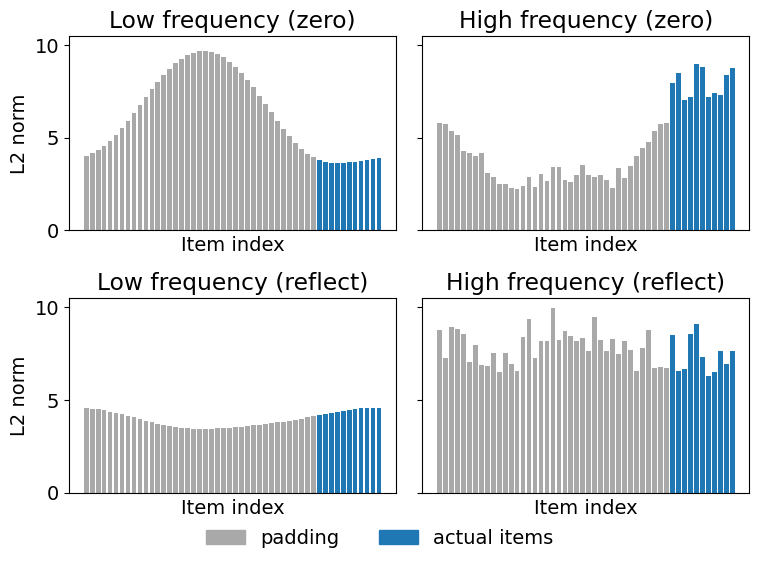

Saved bar plot for user 5 at barplots/user_05_barplots.pdf


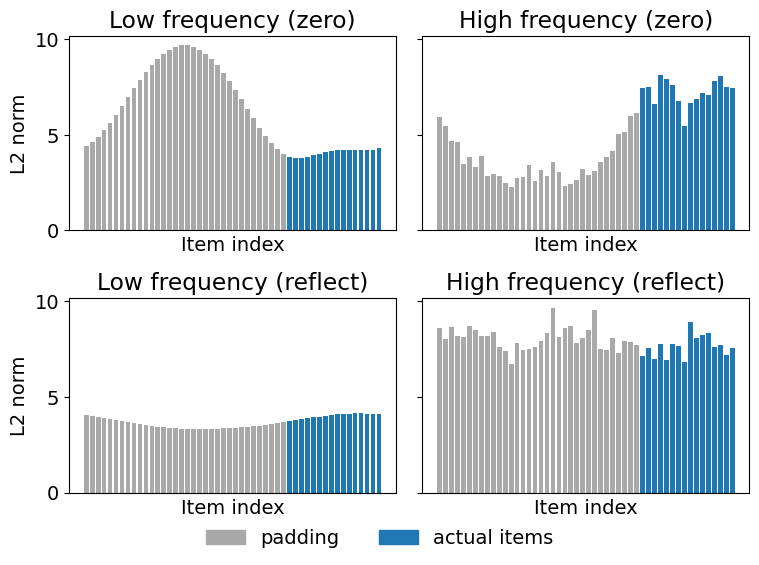

Saved bar plot for user 6 at barplots/user_06_barplots.pdf


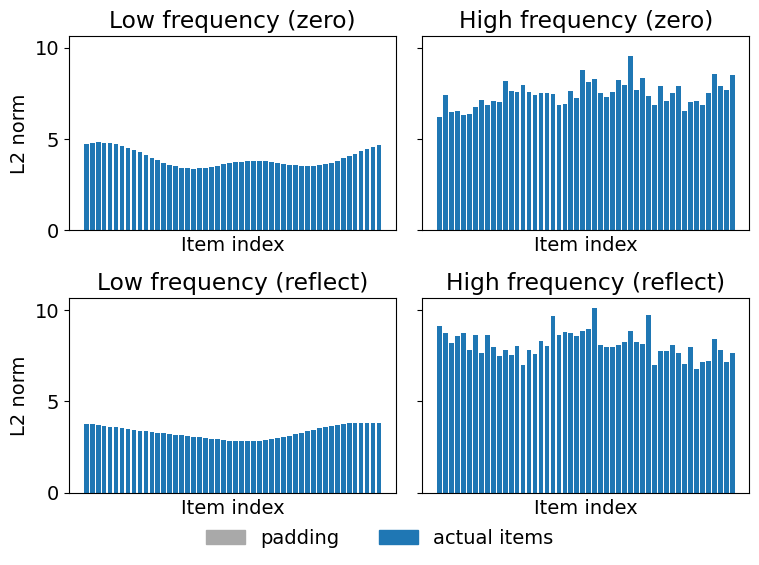

Saved bar plot for user 7 at barplots/user_07_barplots.pdf


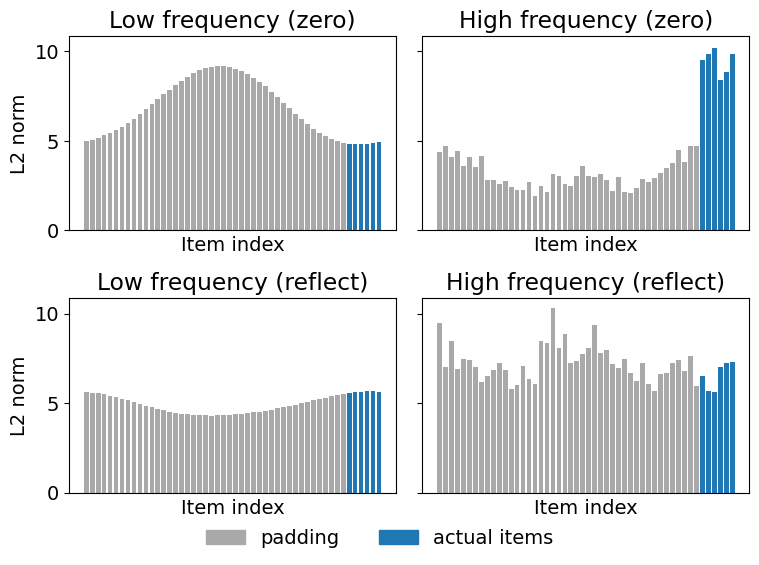

Saved bar plot for user 8 at barplots/user_08_barplots.pdf


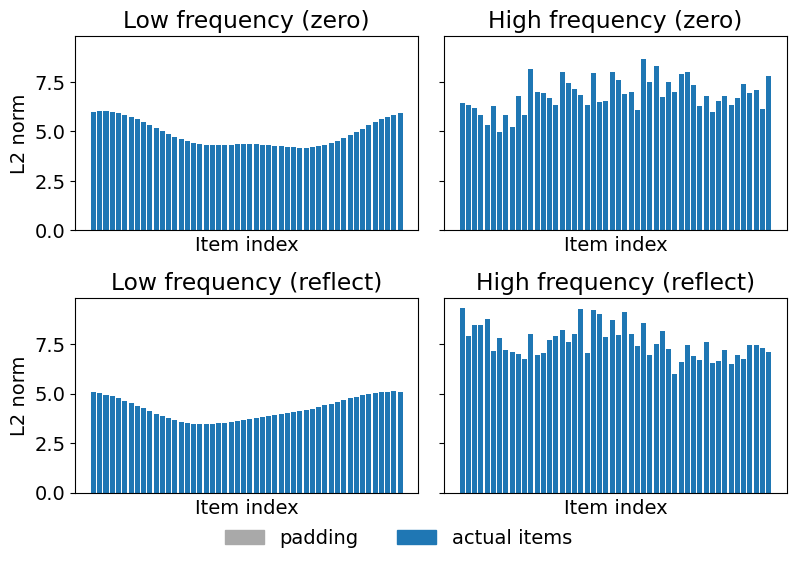

Saved bar plot for user 9 at barplots/user_09_barplots.pdf


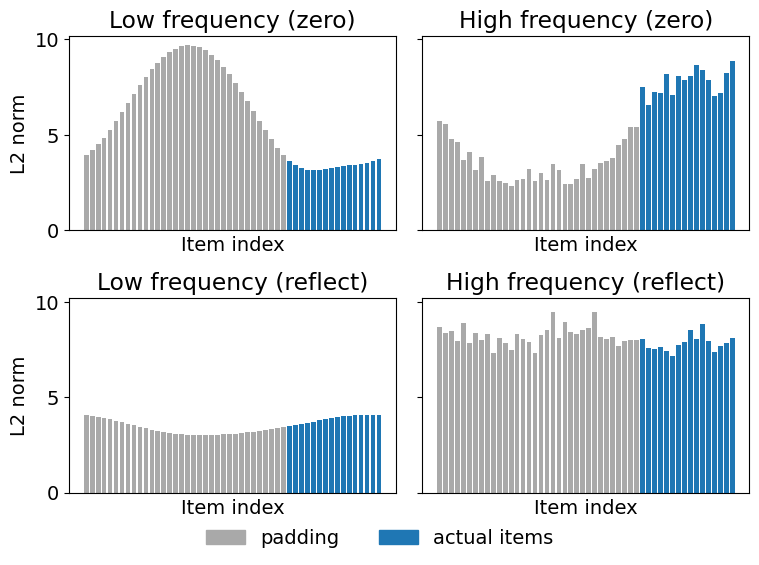

In [46]:
# Plot multiple models
n = 10

tensor_dict_reflect = load_tensor_dict(SAVE_TENSORS_REFLECT_PADDING)
tensor_dict_reflect = compute_l2_norms(tensor_dict_reflect, tensor_names)

tensor_dict_cyclic = load_tensor_dict(SAVE_TENSORS_CIRCULAR_PADDING)
tensor_dict_cyclic = compute_l2_norms(tensor_dict_cyclic, tensor_names)
tensor_dict = load_tensor_dict(SAVE_TENSORS_FILE_BSA_REC)
tensor_dict = compute_l2_norms(tensor_dict, tensor_names)

plot_user_barplots_three(tensor_dict, tensor_dict, tensor_dict_reflect, tensor_dict_cyclic, selected_tensors, inputs="original_input", n_users=n, font_size=14)
